# Canonical Validation

In [1]:
from rdkit import Chem

smi = " N#Cc1c(NC2CCCC2)nc(Cc2ccccc2OC(F)(F)F)[nH]c1=O"

mol = Chem.MolFromSmiles(smi)

canonical = Chem.MolToSmiles(mol, canonical=True)

print("Canonical SMILES:", canonical)

Canonical SMILES: N#Cc1c(NC2CCCC2)nc(Cc2ccccc2OC(F)(F)F)[nH]c1=O


In [1]:
'Cc1cc(-c2ccccc2C(F)(F)F)cc2c1[N]C(C1=NOC3(CCOCC3)C1)=N2' =='Cc1cc(-c2ccccc2C(F)(F)F)cc2nc(C3=NOC4(CCOCC4)C3)[nH]c12'

False

# Checking for Missing Images

In [ ]:
import pandas as pd
import os
df = pd.read_csv('target.csv')
for idx, row in df.iterrows():

        image_path = row["image"]
        target_smiles = row["smiles"]

        if not os.path.exists(image_path):
            print("Missing image:", image_path)

# Finding Files

In [55]:
import os
target = '854666_US08138180-20120320-C00009.png'
dir = '/Users/rohithgowda/Downloads/OpenServer/images/'
for root, dirs, files in  os.walk(dir):
    for file in files :
        if file.endswith(target):
            print(f'File Found at : {os.path.join(dir, file)}')
            break
    else: print('Image Not Found!')

File Found at : /Users/rohithgowda/Downloads/OpenServer/images/854666_US08138180-20120320-C00009.png


# Classification Report

/Users/rohithgowda/miniconda3/envs/OpenServe/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rohithgowda/miniconda3/envs/OpenServe/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rohithgowda/miniconda3/envs/OpenServe/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

Saved report image: classification_report.png


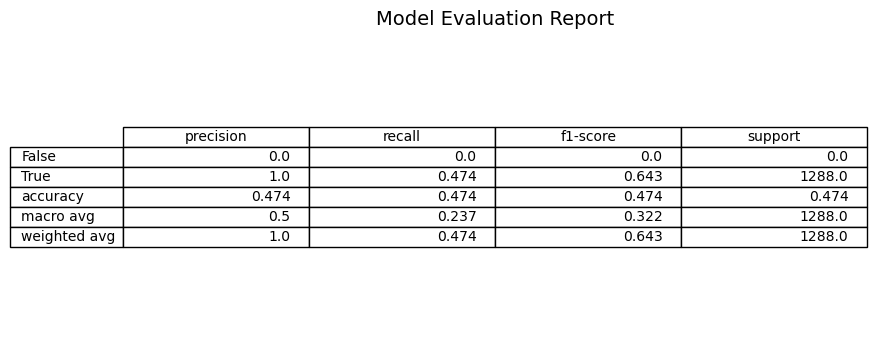

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

CSV_FILE = "evaluation_results.csv"
OUTPUT_IMG = "classification_report.png"

# Load results
df = pd.read_csv(CSV_FILE)

# True labels (all samples should be correct ideally)
y_true = [True] * len(df)

# Model predictions
y_pred = df["match"]

# Generate classification report
report = classification_report(y_true, y_pred, output_dict=True)

# Convert to dataframe
report_df = pd.DataFrame(report).transpose()

# Create figure
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

table = ax.table(
    cellText=report_df.round(3).values,
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Evaluation Report", fontsize=14)
plt.savefig(OUTPUT_IMG, bbox_inches='tight')

print("Saved report image:", OUTPUT_IMG)

# Collecting images of incorrectly predicted Smiles for Error Analysis

In [19]:
import os
import shutil
import pandas as pd

RESULT_CSV = "evaluation_results.csv"
OUTPUT_DIR = "incorrect"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(RESULT_CSV)

count = 0

for row in df.itertuples():

    if not row.match:

        image_path = row.image

        if os.path.exists(image_path):

            dest = os.path.join(OUTPUT_DIR, os.path.basename(image_path))
            shutil.copy(image_path, dest)

            count += 1

print("Incorrect images copied:", count)

Incorrect images copied: 677
